In [282]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-


# Deep Neural Networks

## Session 05a
### Neural Network with :
- One hidden layer 
- ${Tanh}$ activation function
- **multi-class**

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com" align="left"/>

In [283]:
###-----------------
### Import Libraries
###-----------------

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [284]:
###----------------
### Some parameters
###----------------

inpDir = Path('../input')
outDir = Path('../output')

RANDOM_STATE = 0 # REMEMBER: to remove at the time of promotion to production
# np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results
rng = np.random.default_rng(seed=RANDOM_STATE)

EPOCHS = 20001 # number of epochs
ALPHA = 0.1 # learning rate
NUM_SAMPLES = 1280 # How many samples we want to generate 
EPSILON = 1e-15 # to avoid log(0)  []
NOISE = 0.2 # Noise to be introduced in the data
TEST_SIZE = 0.2

# parameters for Matplotlib
params = {'legend.fontsize': 'large',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = 'coolwarm' # plt.cm.Spectral

plt.rcParams.update(params)

## Helper Functions

In [285]:
###-----------------------------------
### Function to plot Decision boundary
###-----------------------------------

def fn_plot_decision_boundary( model:dict, X_tr: np.ndarray, y_tr: np.ndarray, X_ts :  np.ndarray, y_ts:  np.ndarray,):
    '''
        Args:
            model: trained neural network model
            X_tr : train feature matrix
            y_tr : train labels
            X_ts : test feature matrix
            y_ts : test labels
        Return:
            None
    '''
    
    # Set min and max values and give it some padding
    xMin, xMax = X_tr[:, 0].min() - .05, X_tr[:, 0].max() + .05
    yMin, yMax = X_tr[:, 1].min() - .05, X_tr[:, 1].max() + .05
    
    # grid size for mesh grid
    h = 0.01
    
    # Generate a grid of points with distance 'h' between them
    xx, yy = np.meshgrid(np.arange(xMin, xMax, h), np.arange(yMin, yMax, h))
    
    # Predict the function value for the whole grid
    Z = fn_predict(model, np.c_[xx.ravel(), yy.ravel()])
    
    # Make its shape same as that of xx 
    Z = Z.reshape(xx.shape)

    fig = plt.figure()
    ax = fig.add_axes(111)
    
    # Now we have Z value corresponding to each of the combination of xx and yy
    # Plot the contour and training examples
    ax.contourf(xx, yy, Z, cmap=CMAP) #, alpha = 0.8
    
    # Plotting scatter for train data
    ax.scatter(X_tr[:, 0], X_tr[:, 1], 
               c=np.argmax(y_tr, axis = 1), # y_tr has two columns 
               s=30, edgecolor='k', cmap=plt.cm.coolwarm)
    
    
    # Plotting scatter for test data
    ax.scatter(X_ts[:, 0], X_ts[:, 1], 
               c=np.argmax(y_ts, axis = 1), # y_tr has two columns ,
                                  s=150, marker = '*',edgecolor='k', cmap=plt.cm.inferno )


## Generate Data Set
<p style="font-family: Arial; font-size:1.1em">
Use Sklearn's dataset generator <a href="http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html">make_moon</a>.
</p>

In [286]:
X, y = datasets.make_moons(n_samples=NUM_SAMPLES, shuffle=True, noise=NOISE, random_state=RANDOM_STATE)

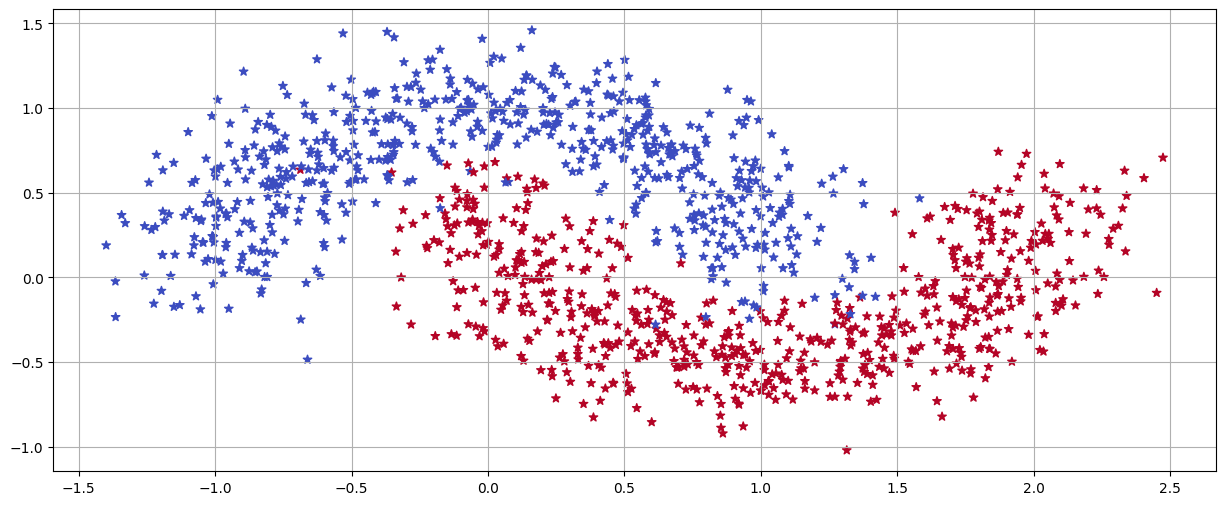

In [287]:
# Lets Plot the data
plt.scatter(X[:,0], X[:,1], s=40, c=y, marker='*', cmap=CMAP)

plt.grid()

In [288]:
###############################
### Make it multi-class data ###
###############################

y = pd.get_dummies(y).to_numpy()
y

array([[False,  True],
       [False,  True],
       [ True, False],
       ...,
       [False,  True],
       [ True, False],
       [False,  True]], shape=(1280, 2))

In [289]:
y.shape

(1280, 2)

In [290]:
#  Split the data in training and test sets to measure performance of the model.
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=TEST_SIZE, 
                                                    random_state=RANDOM_STATE )

print (X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1024, 2) (1024, 2) (256, 2) (256, 2)


## Neural Network

Let's start with simple network. Our data has **two** features. Hence size of input layer will also be two. Lets code our output as two classes. The hidden layer could be of **any size**. One need to execute a handful of iterations to arrive at right size of hidden layer. For purpose of today's discussions, size of hidden layer is taken as shown below.
<img src='../../images/dnn_nb_s05_fig1.jpg' width = '500' alt = 'Session 5 Figure 1'/>

We will be using $\tanh$ function for layer 1 (hidden layer) as it fits in majority of cases and its derivative can simply be represented as 1 -$\tanh^2(z_1)$. Our output is multi-class. We will change our activation function to $\text{Softmax}$ from $\text{Sigmoid}$ in the last layer.

<img src='../../images/dnn_nb_s05_fig2.jpg' width = '500' alt = 'Session 5 fig 2'/>

## Activation Functions

### Softmax Function
Activation function to work with multi-class problems

$\sigma(z_i) = \dfrac{e^{z_i}}{\sum_{j=1}^{K}e^{z_j}}$


In [291]:
def fn_softmax(z : np.ndarray) -> np.ndarray:
    '''
        Args:
           z : array, Aggregated values 
       Return:
           probs. of each class
        NOTE: Subtract max for numerical stability.
        This prevents overflow when z has large values.
    '''
    # Subtract max for numerical stability
    z_shifted = z - np.max(z, axis=1, keepdims=True)     # Jugad to avoid large values of e power z
    
    exp_sc = np.exp(z_shifted)
    
    return exp_sc / np.sum(exp_sc, axis=1, keepdims=True)

In [292]:
sm = fn_softmax(np.asarray([[8, 5, 0], [-10, 0., 10]]))
print (sm, '\n\nTotal of all values', sm.sum(axis = 1))

[[9.52269826e-01 4.74107229e-02 3.19450938e-04]
 [2.06106005e-09 4.53978686e-05 9.99954600e-01]] 

Total of all values [1. 1.]


### Other Activation Function
Keep tanh Function for hidden layer

In [293]:
def fn_activ(z: np.ndarray)-> np.ndarray:

    return np.tanh(z)

def fn_activ_prime(z: np.ndarray)-> np.ndarray:

    return 1.0 - np.tanh(z)**2

## Loss Function
### Loss function will change for Multiclass

We need to minimize the error by adjusting ($Ws, bs$). We call the function that measures our error the <b>loss function</b>. 

For multi-class classification with softmax output, we use <b>categorical cross-entropy</b>:
$
\begin{aligned}L(\hat{y}_i, y_i) = -\sum_{j=1}^{K} y_{ij} \cdot \log(\hat{y}_{ij})
\end{aligned}
$

For all samples:

$
\begin{aligned}
J(\hat{y}, y) =  -\frac{1}{m}\sum_{i=1}^{m}\sum_{j=1}^{K}[y_{ij}.log(\hat{y}_{ij})]
\end{aligned}
$

We can use gradient descent to find its minimum. For purpose of this Session, let's use it in its simplest form - <b>batch gradient descent with fixed learning rate</b>.

### Loss Function

In [294]:
# function to evaluate the total loss on the dataset

def fn_calculate_loss(model : dict, X: np.ndarray, y: np.ndarray) -> np.float64:
    '''
    Args:
        model: dictionay object containing weights and biases
        X: Feature Matrix
        y: Labels array
    Returns:
        Average loss
    '''
    
    # extract weights and biases from the model
    W1, b1 = model['W1'], model['b1']
    W2, b2 = model['W2'], model['b2']
    W3, b3 = model['W3'], model['b3']
    W4, b4 = model['W4'], model['b4']
    W5, b5 = model['W5'], model['b5']

    # number of examples
    m = X.shape[0]
    
    ##########################
    #   Forward propagation  #
    ##########################
    
    # Layer 1
    z1 = X.dot(W1) + b1   #  Aggregation
    a1 = fn_activ(z1)    # Activation function for layer 1
    
    # Layer 2
    z2 = a1.dot(W2) + b2     #  Aggregation
    a2 = fn_activ(z2)       # Activation
    
        # Layer 3
    z3 = a2.dot(W3) + b3     #  Aggregation
    a3 = fn_activ(z3)       # Activation
    
        # Layer 4
    z4 = a3.dot(W4) + b4     #  Aggregation
    a4 = fn_activ(z4)       # Activation
    
        # Layer 5
    z5 = a4.dot(W5) + b5     #  Aggregation
    a5 = fn_softmax(z5)       # Activation
    
    
    eps = EPSILON      # to avoid NaN values while changing wts
    a5 = np.clip(a5, eps, 1 - eps)

    # Element-wise multiplication, then sum over classes
    data_loss = -np.sum(y * np.log(a5))

    return 1./m * data_loss

## Predict Function

For predictions, we will simply be using the forward propagation.

In [295]:
# Helper function to predict an output (0 or 1)

def fn_predict(model : dict, X: np.ndarray) -> np.ndarray:
    '''
     Args:
         model
         X: input features
    Returns:
        Predictions against the instances
         
    '''
    W1, b1 = model['W1'], model['b1']
    W2, b2 = model['W2'], model['b2']
    W3, b3 = model['W3'], model['b3']
    W4, b4 = model['W4'], model['b4']
    W5, b5 = model['W5'], model['b5']
    
    ##########################
    #   Forward propagation  #
    ##########################
    
    # Layer 1
    z1 = X.dot(W1) + b1   #  Aggregation
    a1 = fn_activ(z1)    # Activation function for layer 1
    
    # Layer 2
    z2 = a1.dot(W2) + b2     #  Aggregation
    a2 = fn_activ(z2)       # Activation
    
        # Layer 3
    z3 = a2.dot(W3) + b3     #  Aggregation
    a3 = fn_activ(z3)       # Activation
    
        # Layer 4
    z4 = a3.dot(W4) + b4     #  Aggregation
    a4 = fn_activ(z4)       # Activation
    
        # Layer 5
    z5 = a4.dot(W5) + b5     #  Aggregation
    a5 = fn_softmax(z5)       # Activation
    
    # ###############################
    # ### Changes for multi class ###
    # ###############################  
    # # Softmax Activation
    # a5 = fn_softmax(z5)
    
    return np.argmax(a5, axis =1)  # pick with one with highest probabilities

## Back-propagation for all Rows
For all rows, equations will remain same and the values will be divided by <b><i>'m'</i></b>; number of samples.

$
\begin{aligned}
\partial{z^{[2]}}  & = a^{[2]} - y  \\
\partial{W^{[2]}}  & = \frac{1}{m} a^{[1]T}\circ \partial{z^{[2]}} \\
\partial{b^{[2]}}  & = \frac{1}{m} \mathrm{np.sum}(\partial{z^{[2]}}, axis = 0, keepdims = True) \\
\partial{a^{[1]}}  & = \partial{z^{[2]}} \circ W^{[2]T}\\
\\
\partial{z^{[1]}}  & = \partial{a^{[1]}} * ( 1-z^{[1]}**2)\\
\partial{W^{[1]}}  & = \frac{1}{m} X^{T}\circ \partial{z^{[1]}} \\
\partial{b^{[1]}}  & = \frac{1}{m} \mathrm{np.sum}(\partial{z^{[1]}}, axis = 0, keepdims = True) \\
\\
\end{aligned}
$


# Notes:


We have transposed a few matrices in above calculations such as $a^{[1]}$, $W^{[2]}$ and X. A review of shapes of matrices will reveal that this adjustment is needed to have consistent sizes. e.g.

- Shape of $a^{[1]}$ and $\partial{z}^{[2]}$ are ( m, 4) and ( m, 1 ) respectively. Expected shape of $\partial{W^{[2]}}$ is ( 4, 1 ) which is same as that of $W^{[2]}$.
- In equation $\partial{z^{[1]}}  = \partial{z^{[2]}}\circ  W^{[2]T} * ( 1-z^{[1]}**2)$ shape of $z^{[2]}$,  $W^{[2]}$ and $a^{[1]}$ are (m,1), (4,1) and (m,4). For element wise multiplication, expected shape of dot product of is $z^{[2]}$ and $W^{[2]}$ is ( m, 4 ).
- Lastly, shape of $\partial{W^{[1]}}$ is (2,4) and that of X and $\partial{z^{[1]}}$ are ( m, 2 ) and ( m, 4 ).

## Prepare Model:

In [296]:
from tkinter import W


def fn_build_model(param : dict, 
                X : np.ndarray, 
                y : np.ndarray, 
                epochs: np.int64 = EPOCHS, 
                alpha: np.float64 = ALPHA) -> dict:
    
    '''
    Args:
        nn_hdim : Number of nodes in the hidden layer
        X : Training features to train
        y : Training targets (labels)
        epochs : Number of passes through the training data for gradient descent
        alpha : learning rate
        
    Returns:
        Model: Dictionary object containing weights and biases
    '''
    # number of examples
    m = X.shape[0]
    nn_input_dim = X.shape[1]
    nn_output_dim = y.shape[1]

    # Initialize the parameters to random values. We need to learn these.
    # Weights
    #fixed this
    W1 = rng.standard_normal((param['nn_hdim'][0], param['nn_hdim'][1])) / np.sqrt(param['nn_hdim'][0])    #(2,5)
    
    W2 = rng.standard_normal((param['nn_hdim'][1], param['nn_hdim'][2])) / np.sqrt(param['nn_hdim'][1])    #(5,5)
    
    W3 = rng.standard_normal((param['nn_hdim'][2], param['nn_hdim'][3])) / np.sqrt(param['nn_hdim'][2])    #(5,4)
    
    W4 = rng.standard_normal((param['nn_hdim'][3], param['nn_hdim'][4])) / np.sqrt(param['nn_hdim'][3])    #(4,3)
    
    W5 = rng.standard_normal((param['nn_hdim'][4], nn_output_dim)) / np.sqrt(param['nn_hdim'][4])          #(3,2)
    
    '''NOTE: For tanh, zero-centered inputs are especially important 
    because it is symmetric around zero. Poor initialization can push 
    activations into saturation, slowing gradient flow.'''
    
    # Bias
    b1 = np.zeros((1, param['nn_hdim'][1]))
    b2 = np.zeros((1, param['nn_hdim'][2]))
    b3 = np.zeros((1, param['nn_hdim'][3]))
    b4 = np.zeros((1, param['nn_hdim'][4]))
    b5 = np.zeros((1, nn_output_dim))
    
    curr_loss = 0
    loss = []
    epoch = []
    
    # Gradient descent. For each batch...
    for i in range(0, epochs):
        
        ##########################
        #   Forward propagation  #
        ##########################
        
        # Layer 1
        z1 = X.dot(W1) + b1   #  Aggregation
        a1 = fn_activ(z1)    # Activation function for layer 1
        
        # Layer 2
        z2 = a1.dot(W2) + b2     #  Aggregation
        a2 = fn_activ(z2)       # Activation
        
         # Layer 3
        z3 = a2.dot(W3) + b3     #  Aggregation
        a3 = fn_activ(z3)       # Activation
        
         # Layer 4
        z4 = a3.dot(W4) + b4     #  Aggregation
        a4 = fn_activ(z4)       # Activation
        
         # Layer 5
        z5 = a4.dot(W5) + b5     #  Aggregation
        a5 = fn_softmax(z5)       # Activation
        
        ###############################
        ### Changes for multi class ###
        ###############################
        # an = fn_softmax(z2)

        #######################
        #   Back propagation  #
        #######################
        
        # Layer 5
        dz5 = a5-y

        dW5 = (a4.T).dot(dz5)
        assert(W5.shape == dW5.shape), 'Shape of W5 {} and dW5 {} do not match'.format(W5.shape, dW5.shape)
        
        db5 = np.sum(dz5, axis=0, keepdims=True) # db2 is sum along axis 0
        assert(b5.shape == db5.shape), 'Shape of b5 {} and db5 {} do not match'.format(b5.shape, db5.shape)
        
        da4 = dz5.dot(W5.T)
        assert (a4.shape == da4.shape), 'Shape of a4 {} and shape of da4 {}'.format(a4.shape, da4.shape)
        
        
         # Layer 4
        dz4 = da4 * fn_activ_prime(z4)  #derivative of Activation Function

        dW4 = (a3.T).dot(dz4)
        assert(W4.shape == dW4.shape), 'Shape of W4 {} and dW4 {} do not match'.format(W4.shape, dW4.shape)
        
        db4 = np.sum(dz4, axis=0, keepdims=True) # db2 is sum along axis 0
        assert(b4.shape == db4.shape), 'Shape of b4 {} and db4 {} do not match'.format(b4.shape, db4.shape)
        
        da3 = dz4.dot(W4.T)
        assert (a3.shape == da3.shape), 'Shape of a3 {} and shape of da3 {}'.format(a3.shape, da3.shape)
        

        # Layer 3
        dz3 = da3 * fn_activ_prime(z3)  #derivative of Activation Function
        
        dW3 = (a2.T).dot(dz3)
        assert(W3.shape == dW3.shape), 'Shape of W3 {} and dW3 {} do not match'.format(W3.shape, dW3.shape)
        
        db3 = np.sum(dz3, axis=0, keepdims=True) # db2 is sum along axis 0
        assert(b3.shape == db3.shape), 'Shape of b3 {} and db3 {} do not match'.format(b3.shape, db3.shape)
        
        da2 = dz3.dot(W3.T)
        assert (a2.shape == da2.shape), 'Shape of a2 {} and shape of da2 {}'.format(a2.shape, da2.shape)
        
        # Layer 2
        dz2 = da2 * fn_activ_prime(z2)  #derivative of Activation Function  
        
        dW2 = (a1.T).dot(dz2)
        assert(W2.shape == dW2.shape), 'Shape of W2 {} and dW2 {} do not match'.format(W2.shape, dW2.shape)
        
        db2 = np.sum(dz2, axis=0, keepdims=True) # db2 is sum along axis 0
        assert(b2.shape == db2.shape), 'Shape of b2 {} and db2 {} do not match'.format(b2.shape, db2.shape)
        
        da1 = dz2.dot(W2.T)
        assert (a1.shape == da1.shape), 'Shape of a1 {} and shape of da1 {}'.format(a1.shape, da1.shape)
        
        
        # Layer 1
        dz1 = da1 * fn_activ_prime(z1)  #derivative of Activation Function
        #                               '*' indicates element wise multiplication
        assert(z1.shape == dz1.shape), 'Shape of z1 {} and dz1 {} do not match'.format(W2.shape, dW2.shape)
        
        dW1 = np.dot(X.T, dz1)
        assert(W1.shape == dW1.shape), 'Shape of W1 {} and dW1 {} do not match'.format(W1.shape, dW1.shape)
        
        db1 = np.sum(dz1, axis=0, keepdims=True) 
        assert(b1.shape == db1.shape), 'Shape of b1 {} and db1 {} do not match'.format(b1.shape, db1.shape)
        
        # Gradient descent parameter update
        W1 += -alpha * dW1/m        
        W2 += -alpha * dW2/m
        W3 += -alpha * dW3/m
        W4 += -alpha * dW4/m
        W5 += -alpha * dW5/m
                
        b1 += -alpha * db1/m
        b2 += -alpha * db2/m
        b3 += -alpha * db3/m
        b4 += -alpha * db4/m
        b5 += -alpha * db5/m
        
        #  Model as a Dict object to be return.
        # Assign new parameters to the model
        model = { 'W1': W1, 'b1': b1,   # Layer 1
                 'W2': W2, 'b2': b2,    # Layer 2
                 'W3': W3, 'b3': b3,    # Layer 3
                 'W4': W4, 'b4': b4,    # Layer 4
                 'W5': W5, 'b5': b5 }   # Layer 5
        
        if i % 100 == 0: # Record loss every 100 epochs
            curr_loss = fn_calculate_loss(model, X, y)
            loss.append(curr_loss)
            epoch.append(i)
        
        # Print the loss.
        if i % 1000 == 0:
            print("Loss after iteration %5i: %.5f" %(i, curr_loss))
    
    loss_hist['epoch'] = epoch
    loss_hist['loss'] = loss
    
    return model

In [297]:
# lists to facilitate plotting 
loss_hist = {}
layer_param = {}
layer_param['nn_hdim'] = [X_train.shape[1], 5, 5, 4, 3]


In [298]:
# Build a model with a multiple hidden layer
model = fn_build_model(layer_param, X_train, y_train,
                    epochs = EPOCHS, 
                    alpha = ALPHA)

Loss after iteration     0: 0.74611


Loss after iteration  1000: 0.06765
Loss after iteration  2000: 0.05720
Loss after iteration  3000: 0.05464
Loss after iteration  4000: 0.05367
Loss after iteration  5000: 0.05320
Loss after iteration  6000: 0.05276
Loss after iteration  7000: 0.05222
Loss after iteration  8000: 0.05218
Loss after iteration  9000: 0.05158
Loss after iteration 10000: 0.05084
Loss after iteration 11000: 0.04997
Loss after iteration 12000: 0.04901
Loss after iteration 13000: 0.04807
Loss after iteration 14000: 0.04726
Loss after iteration 15000: 0.04660
Loss after iteration 16000: 0.04607
Loss after iteration 17000: 0.04565
Loss after iteration 18000: 0.04529
Loss after iteration 19000: 0.04498
Loss after iteration 20000: 0.04469


In [299]:
model

{'W1': array([[-1.6268484 , -0.57812689,  1.56344666, -0.99664965, -2.44758358],
        [ 0.86115578, -0.15531444, -0.99273875, -0.06106117, -1.26074227]]),
 'b1': array([[1.6172089 , 0.23133887, 0.31095984, 1.06419562, 1.78783364]]),
 'W2': array([[-0.36905514, -0.230907  , -2.49895218, -0.18729684, -1.06020688],
        [-0.21472319, -0.88135149, -0.37773024, -0.4331411 ,  0.14911852],
        [-0.18640784,  1.07116814, -0.27242914,  0.49122742,  0.78089858],
        [ 0.0391298 , -0.57634855, -1.07693442, -0.52390526, -0.08430317],
        [ 0.11820567,  1.80014589, -0.47267196,  1.42001115, -0.61129105]]),
 'b2': array([[-0.20684513, -0.10601383, -0.22332754,  0.11141895,  0.07780865]]),
 'W3': array([[ 0.04393142, -0.23131068, -0.10634457,  0.25621811],
        [ 1.08376667, -0.7010845 ,  1.36484774,  1.20564605],
        [ 0.70573696,  0.01219959,  0.52364246,  1.48290519],
        [ 1.2016962 ,  0.62486477,  1.08802243,  0.60209142],
        [-1.04484797,  0.10081488,  0.014203

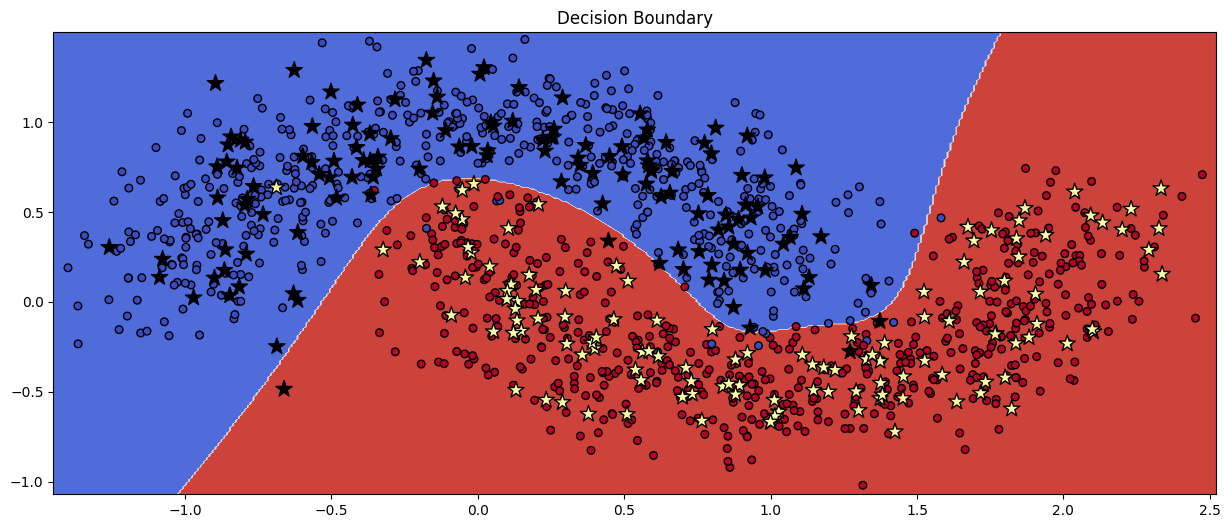

In [300]:
loss_df = pd.DataFrame(loss_hist)

fn_plot_decision_boundary(model, X_train, y_train, X_test, y_test) # plot decision boundary for this plot

plt.title("Decision Boundary");

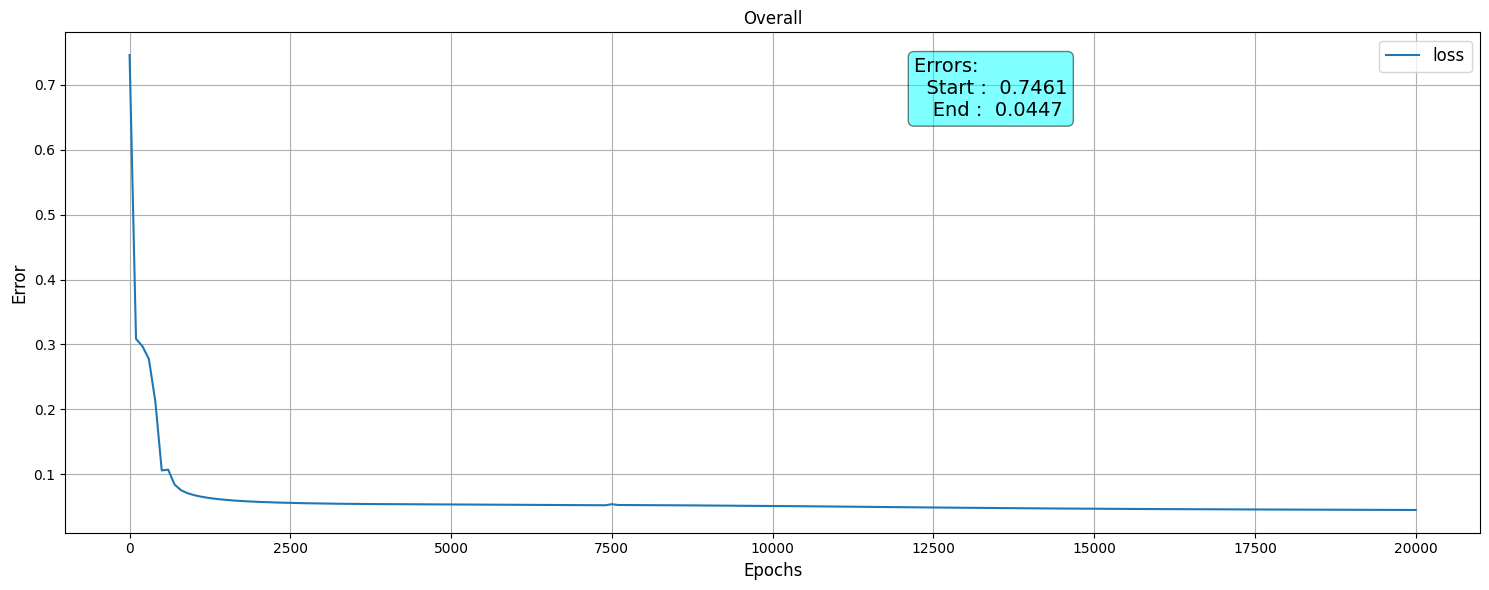

In [301]:
fig, ax = plt.subplots()

loss_df.plot(x = 'epoch', y = 'loss', ax = ax)

# little beautification
txtstr = "Errors: \n  Start : {:7.4f}\n   End : {:7.4f}".format(loss_df.iloc[0]['loss'],
                                                                loss_df.iloc[-1]['loss']) #text to plot

# properties  matplotlib.patch.Patch 
props = dict(boxstyle='round', facecolor='aqua', alpha=0.5)

# place a text box in upper left in axes coords

ax.text(0.6, 0.95, txtstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

ax.set_xlabel("Epochs")
ax.set_ylabel("Error")
ax.set_title('Overall')
ax.grid(True);

plt.tight_layout()

# Check for overfitting

# With Different value of Alpha = 0.01

In [302]:
from tkinter import W

ALPHA = 0.01 # learning rate

def fn_build_model(param : dict, 
                X : np.ndarray, 
                y : np.ndarray, 
                epochs: np.int64 = EPOCHS, 
                alpha: np.float64 = ALPHA) -> dict:
    
    '''
    Args:
        nn_hdim : Number of nodes in the hidden layer
        X : Training features to train
        y : Training targets (labels)
        epochs : Number of passes through the training data for gradient descent
        alpha : learning rate
        
    Returns:
        Model: Dictionary object containing weights and biases
    '''
    # number of examples
    m = X.shape[0]
    nn_input_dim = X.shape[1]
    nn_output_dim = y.shape[1]

    # Initialize the parameters to random values. We need to learn these.
    # Weights
    #fixed this
    W1 = rng.standard_normal((param['nn_hdim'][0], param['nn_hdim'][1])) / np.sqrt(param['nn_hdim'][0])    #(2,5)
    
    W2 = rng.standard_normal((param['nn_hdim'][1], param['nn_hdim'][2])) / np.sqrt(param['nn_hdim'][1])    #(5,5)
    
    W3 = rng.standard_normal((param['nn_hdim'][2], param['nn_hdim'][3])) / np.sqrt(param['nn_hdim'][2])    #(5,4)
    
    W4 = rng.standard_normal((param['nn_hdim'][3], param['nn_hdim'][4])) / np.sqrt(param['nn_hdim'][3])    #(4,3)
    
    W5 = rng.standard_normal((param['nn_hdim'][4], nn_output_dim)) / np.sqrt(param['nn_hdim'][4])          #(3,2)
    
    '''NOTE: For tanh, zero-centered inputs are especially important 
    because it is symmetric around zero. Poor initialization can push 
    activations into saturation, slowing gradient flow.'''
    
    # Bias
    b1 = np.zeros((1, param['nn_hdim'][1]))
    b2 = np.zeros((1, param['nn_hdim'][2]))
    b3 = np.zeros((1, param['nn_hdim'][3]))
    b4 = np.zeros((1, param['nn_hdim'][4]))
    b5 = np.zeros((1, nn_output_dim))
    
    curr_loss = 0
    loss = []
    epoch = []
    
    # Gradient descent. For each batch...
    for i in range(0, epochs):
        
        ##########################
        #   Forward propagation  #
        ##########################
        
        # Layer 1
        z1 = X.dot(W1) + b1   #  Aggregation
        a1 = fn_activ(z1)    # Activation function for layer 1
        
        # Layer 2
        z2 = a1.dot(W2) + b2     #  Aggregation
        a2 = fn_activ(z2)       # Activation
        
         # Layer 3
        z3 = a2.dot(W3) + b3     #  Aggregation
        a3 = fn_activ(z3)       # Activation
        
         # Layer 4
        z4 = a3.dot(W4) + b4     #  Aggregation
        a4 = fn_activ(z4)       # Activation
        
         # Layer 5
        z5 = a4.dot(W5) + b5     #  Aggregation
        a5 = fn_softmax(z5)       # Activation
        
        ###############################
        ### Changes for multi class ###
        ###############################
        # an = fn_softmax(z2)

        #######################
        #   Back propagation  #
        #######################
        
        # Layer 5
        dz5 = a5-y

        dW5 = (a4.T).dot(dz5)
        assert(W5.shape == dW5.shape), 'Shape of W5 {} and dW5 {} do not match'.format(W5.shape, dW5.shape)
        
        db5 = np.sum(dz5, axis=0, keepdims=True) # db2 is sum along axis 0
        assert(b5.shape == db5.shape), 'Shape of b5 {} and db5 {} do not match'.format(b5.shape, db5.shape)
        
        da4 = dz5.dot(W5.T)
        assert (a4.shape == da4.shape), 'Shape of a4 {} and shape of da4 {}'.format(a4.shape, da4.shape)
        
        
         # Layer 4
        dz4 = da4 * fn_activ_prime(z4)  #derivative of Activation Function

        dW4 = (a3.T).dot(dz4)
        assert(W4.shape == dW4.shape), 'Shape of W4 {} and dW4 {} do not match'.format(W4.shape, dW4.shape)
        
        db4 = np.sum(dz4, axis=0, keepdims=True) # db2 is sum along axis 0
        assert(b4.shape == db4.shape), 'Shape of b4 {} and db4 {} do not match'.format(b4.shape, db4.shape)
        
        da3 = dz4.dot(W4.T)
        assert (a3.shape == da3.shape), 'Shape of a3 {} and shape of da3 {}'.format(a3.shape, da3.shape)
        

        # Layer 3
        dz3 = da3 * fn_activ_prime(z3)  #derivative of Activation Function
        
        dW3 = (a2.T).dot(dz3)
        assert(W3.shape == dW3.shape), 'Shape of W3 {} and dW3 {} do not match'.format(W3.shape, dW3.shape)
        
        db3 = np.sum(dz3, axis=0, keepdims=True) # db2 is sum along axis 0
        assert(b3.shape == db3.shape), 'Shape of b3 {} and db3 {} do not match'.format(b3.shape, db3.shape)
        
        da2 = dz3.dot(W3.T)
        assert (a2.shape == da2.shape), 'Shape of a2 {} and shape of da2 {}'.format(a2.shape, da2.shape)
        
        # Layer 2
        dz2 = da2 * fn_activ_prime(z2)  #derivative of Activation Function  
        
        dW2 = (a1.T).dot(dz2)
        assert(W2.shape == dW2.shape), 'Shape of W2 {} and dW2 {} do not match'.format(W2.shape, dW2.shape)
        
        db2 = np.sum(dz2, axis=0, keepdims=True) # db2 is sum along axis 0
        assert(b2.shape == db2.shape), 'Shape of b2 {} and db2 {} do not match'.format(b2.shape, db2.shape)
        
        da1 = dz2.dot(W2.T)
        assert (a1.shape == da1.shape), 'Shape of a1 {} and shape of da1 {}'.format(a1.shape, da1.shape)
        
        
        # Layer 1
        dz1 = da1 * fn_activ_prime(z1)  #derivative of Activation Function
        #                               '*' indicates element wise multiplication
        assert(z1.shape == dz1.shape), 'Shape of z1 {} and dz1 {} do not match'.format(W2.shape, dW2.shape)
        
        dW1 = np.dot(X.T, dz1)
        assert(W1.shape == dW1.shape), 'Shape of W1 {} and dW1 {} do not match'.format(W1.shape, dW1.shape)
        
        db1 = np.sum(dz1, axis=0, keepdims=True) 
        assert(b1.shape == db1.shape), 'Shape of b1 {} and db1 {} do not match'.format(b1.shape, db1.shape)
        
        # Gradient descent parameter update
        W1 += -alpha * dW1/m        
        W2 += -alpha * dW2/m
        W3 += -alpha * dW3/m
        W4 += -alpha * dW4/m
        W5 += -alpha * dW5/m
                
        b1 += -alpha * db1/m
        b2 += -alpha * db2/m
        b3 += -alpha * db3/m
        b4 += -alpha * db4/m
        b5 += -alpha * db5/m
        
        #  Model as a Dict object to be return.
        # Assign new parameters to the model
        model = { 'W1': W1, 'b1': b1,   # Layer 1
                 'W2': W2, 'b2': b2,    # Layer 2
                 'W3': W3, 'b3': b3,    # Layer 3
                 'W4': W4, 'b4': b4,    # Layer 4
                 'W5': W5, 'b5': b5 }   # Layer 5
        
        if i % 100 == 0: # Record loss every 100 epochs
            curr_loss = fn_calculate_loss(model, X, y)
            loss.append(curr_loss)
            epoch.append(i)
        
        # Print the loss.
        if i % 1000 == 0:
            print("Loss after iteration %5i: %.5f" %(i, curr_loss))
    
    loss_hist['epoch'] = epoch
    loss_hist['loss'] = loss
    
    return model

In [303]:
# lists to facilitate plotting 
loss_hist = {}
layer_param = {}
layer_param['nn_hdim'] = [X_train.shape[1], 5, 5, 4, 3]


In [304]:
# Build a model with a multiple hidden layer
model = fn_build_model(layer_param, X_train, y_train,
                    epochs = EPOCHS, 
                    alpha = ALPHA)

Loss after iteration     0: 0.67373
Loss after iteration  1000: 0.32930
Loss after iteration  2000: 0.22384
Loss after iteration  3000: 0.10806
Loss after iteration  4000: 0.07457
Loss after iteration  5000: 0.06530
Loss after iteration  6000: 0.06154
Loss after iteration  7000: 0.05963
Loss after iteration  8000: 0.05851
Loss after iteration  9000: 0.05779
Loss after iteration 10000: 0.05727
Loss after iteration 11000: 0.05688
Loss after iteration 12000: 0.05657
Loss after iteration 13000: 0.05632
Loss after iteration 14000: 0.05610
Loss after iteration 15000: 0.05591
Loss after iteration 16000: 0.05575
Loss after iteration 17000: 0.05560
Loss after iteration 18000: 0.05547
Loss after iteration 19000: 0.05534
Loss after iteration 20000: 0.05523


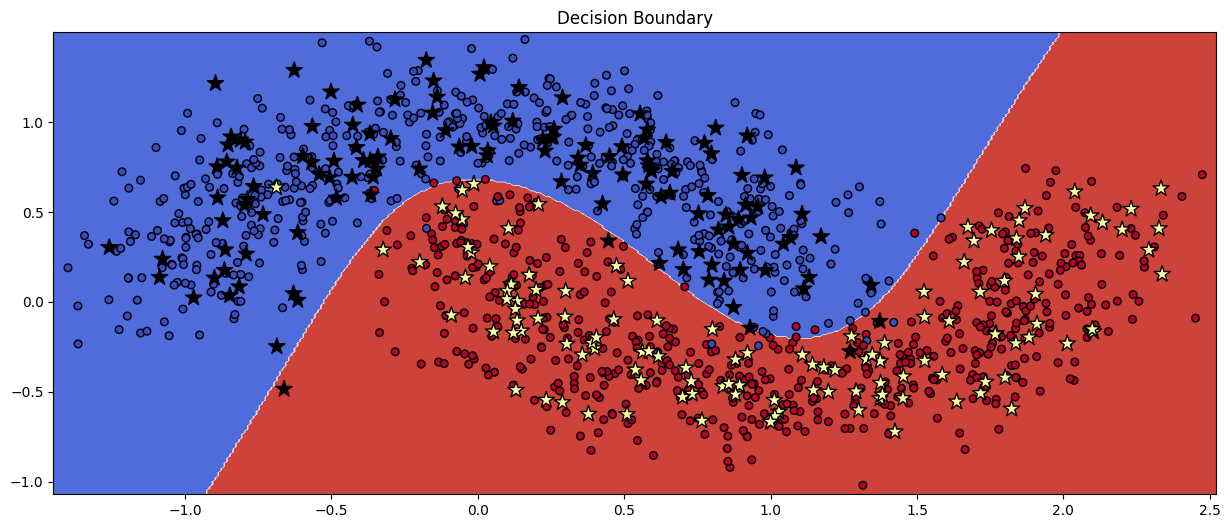

In [305]:
loss_df = pd.DataFrame(loss_hist)

fn_plot_decision_boundary(model, X_train, y_train, X_test, y_test) # plot decision boundary for this plot

plt.title("Decision Boundary");

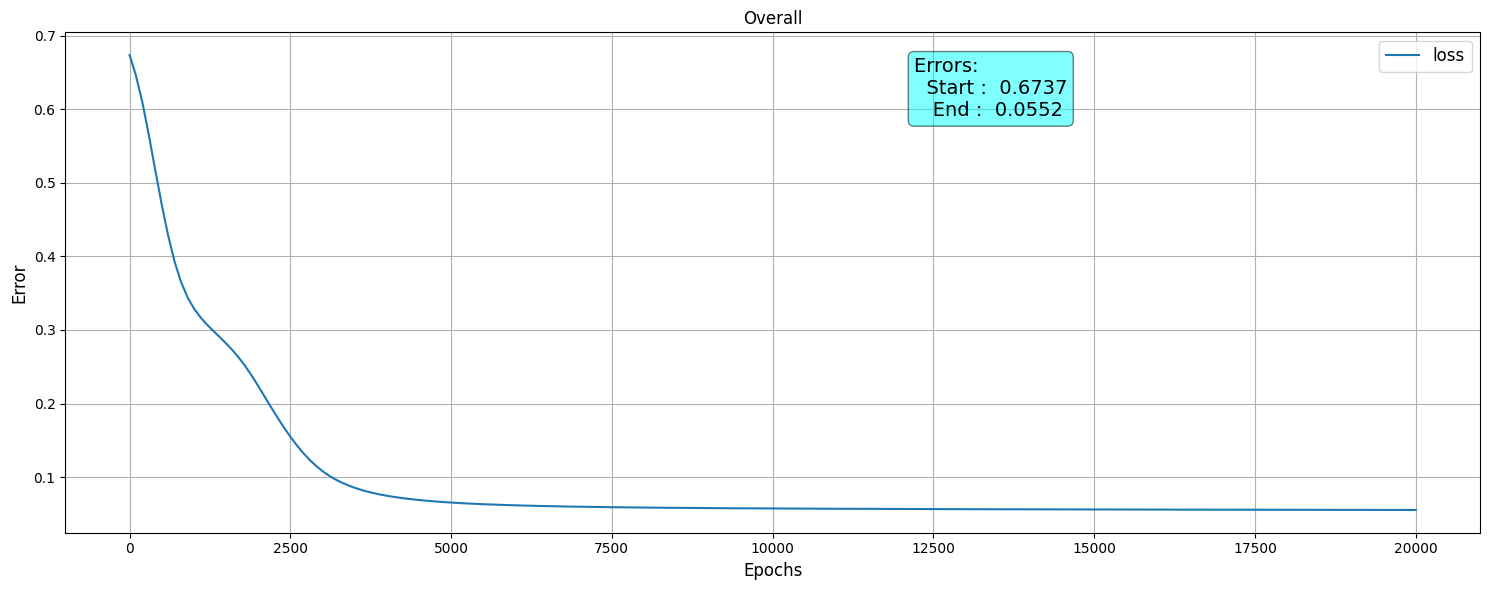

In [306]:
fig, ax = plt.subplots()

loss_df.plot(x = 'epoch', y = 'loss', ax = ax)

# little beautification
txtstr = "Errors: \n  Start : {:7.4f}\n   End : {:7.4f}".format(loss_df.iloc[0]['loss'],
                                                                loss_df.iloc[-1]['loss']) #text to plot

# properties  matplotlib.patch.Patch 
props = dict(boxstyle='round', facecolor='aqua', alpha=0.5)

# place a text box in upper left in axes coords

ax.text(0.6, 0.95, txtstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

ax.set_xlabel("Epochs")
ax.set_ylabel("Error")
ax.set_title('Overall')
ax.grid(True);

plt.tight_layout()

## Predictions
### Train Data

In [307]:
y_pred = fn_predict(model, X_train)
print('Accuracy score on Train Data :', accuracy_score(np.argmax(y_train, axis =1), y_pred))

Accuracy score on Train Data : 0.982421875


In [308]:
print(classification_report(np.argmax(y_train, axis =1), y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       507
           1       0.98      0.98      0.98       517

    accuracy                           0.98      1024
   macro avg       0.98      0.98      0.98      1024
weighted avg       0.98      0.98      0.98      1024



### Test Data

In [309]:
y_pred = fn_predict(model, X_test)

print('Accuracy score on Test Data :', accuracy_score(np.argmax(y_test, axis = 1), y_pred))

Accuracy score on Test Data : 0.98046875


In [310]:
print(classification_report(np.argmax(y_test, axis = 1), y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       133
           1       0.97      0.99      0.98       123

    accuracy                           0.98       256
   macro avg       0.98      0.98      0.98       256
weighted avg       0.98      0.98      0.98       256



In [311]:
## Confusion Matrix helps

cm  = confusion_matrix(np.argmax(y_test, axis = 1), y_pred)
cm

array([[129,   4],
       [  1, 122]])

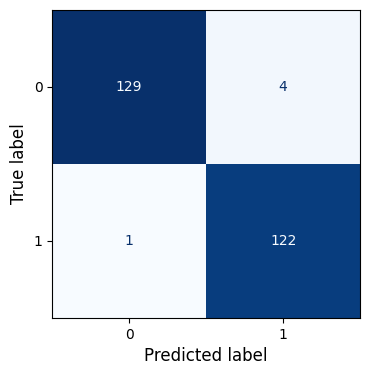

In [312]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0,1])

fig, ax = plt.subplots(figsize = (4,4))

disp.plot(ax = ax, cmap = 'Blues', colorbar=False)

plt.show();

### Remember
#### Binary Classification (1 output neuron + Sigmoid)
Neural Network Output: ONE number between 0 and 1

Example: $\hat{y}$ = 0.85

This SINGLE number means: "Probability of being Class 1"
- Probability of Class 1 = $\hat{y}$ = 0.85
- Probability of Class 0 = 1-$\hat{y}$ = 0.15 *(calculated, not output!)*

So ONE output tells us about BOTH classes implicitly.


#### Multi-Class Classification - Categorical cross-entropy (K output neurons + Softmax)
Neural Network Output: K numbers that sum to 1

Example: ŷ = [0.10, 0.85, 0.05]

EACH number means: "Probability of being that specific class"
- Probability of Class 0 = $\hat{y}_{0}$ = 0.10
- Probability of Class 1 = $\hat{y}_{1}$ = 0.85  
- Probability of Class 2 = $\hat{y}_{2}$ = 0.05

So K outputs tell us about EACH class explicitly.

|Binary Classification|	Multi-Class Classification|
|:-:|:-:|
|Only 2 classes|3+ classes (or 2 with one-hot)
|Single output neuron|Multiple output neurons (one per class)
|Predicts probability of "positive" class|Predicts probability distribution across classes
|$P(class=1)=\hat{y}$|$P(class=j)=\hat{y}_{j}$
|$P(class=0)=1−\hat{y}$ (implied)|Probabilities sum to 1: $\sum_{j=1}^{K}\hat{y}_{j}=1$

### Loss Calculation Comparison
#### Binary Classification Case
**True label:** y = 0 (Class 0)
**Network output:** $\hat{y}$ =  0.15 (probability of Class being 1)

What we know:
- Probability of Class 1 = 0.15 (explicit)
- Probability of Class 0 = 1 - 0.15 = 0.85 (calculated)

$
\begin{aligned}
\text{Loss} &= -[y \cdot \log(\hat{y}) + (1-y) \cdot \log(1-\hat{y})] \\
            &= -[0 \cdot \log(0.85) + 1 \cdot \log(0.15)] \\
            &= -\log(0.15) \\ 
\end{aligned}
$
- We need  $\log(1-\hat{y})$ to access Class 0 probability! Otherwise, error contributions will not be considered for all rows where **True label** is 0!

#### Multi-Class Classification Case
**True label:** y = [0, 1, 0] (Class 1 is true)
**Network output:** $\hat{y}$ = [0.10, 0.85, 0.05]

What we know:
- Probability of Class 0 = 0.10 (explicit - neuron 0 output)
- Probability of Class 1 = 0.85 (explicit - neuron 1 output)
- Probability of Class 2 = 0.05 (explicit - neuron 2 output)

$
\begin{aligned}
\text{Loss} &= -[y_{0} \cdot \log(\hat{y}_{0}) + y_{1}\cdot \log(\hat{y}_{1}) + y_{2}\cdot \log(\hat{y}_{2})] \\
     &= -[0 \cdot \log(0.10) + 1 \cdot \log(0.85) + 0 \cdot \log(0.05)] \\
     &= -[0 + \log(0.85) + 0] \\
     &= -\log(0.85)
\end{aligned}
$
- NO log(1-$\hat{y}$) needed because Class 0 probability is directly $\hat{y}_{0}$!

### Mathematical Equivalence
#### Binary as a Special Case of Multi-Class

For 2 classes (K=2), multi-class becomes:

$
\begin{aligned}
y &= [1, 0] \text{ for Class 0, or [0, 1] for Class 1} \\
\hat{y} &= [\hat{y}_{0}, \hat{y}_{1}] \text{ where } \hat{y}_{0} + \hat{y}_{1} = 1 \\
\text{Loss} &= -[y_{0} \cdot \log(\hat{y}_{0}) + y_{1} \cdot \log(\hat{y}_{1})] \\
\text{Binary is equivalent if we set:} \\
\hat{y}_{1} &= \hat{y} \text{ (probability of Class 1)} &\\
\hat{y}_{0} &= 1-\hat{y} \text{ (probability of Class 0)} &\\
\text{Then binary loss becomes:} &\\
\text{For } y &= [0,1] \text{ (Class 1 true):} &\\
\text{Loss} &= -[0 \cdot \log(1-\hat{y}) + 1 \cdot \log(\hat{y})] = -\log(\hat{y}) \quad \checkmark &\\
\text{For } y &= [1,0] \text{ (Class 0 true):} &\\
\text{Loss} &= -[1 \cdot \log(1-\hat{y}) + 0 \cdot \log(\hat{y})] = -\log(1-\hat{y}) \quad \checkmark &
\end{aligned}
$